# ARTI 404 Assignment: Image Denoising Using Spatial and Frequency Domain Methods

In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [20]:
DATASET = "dataset"

image_names = [
    "camera",
    "coins",
    "text",
    "rice",
    "astronaut"
]

# -------------------------
# Load image
# -------------------------
def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise FileNotFoundError(f"Could not load image: {path}")

    # Convert OpenCV BGR to RGB for color images so matplotlib displays correctly.
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img

# Noise Identification

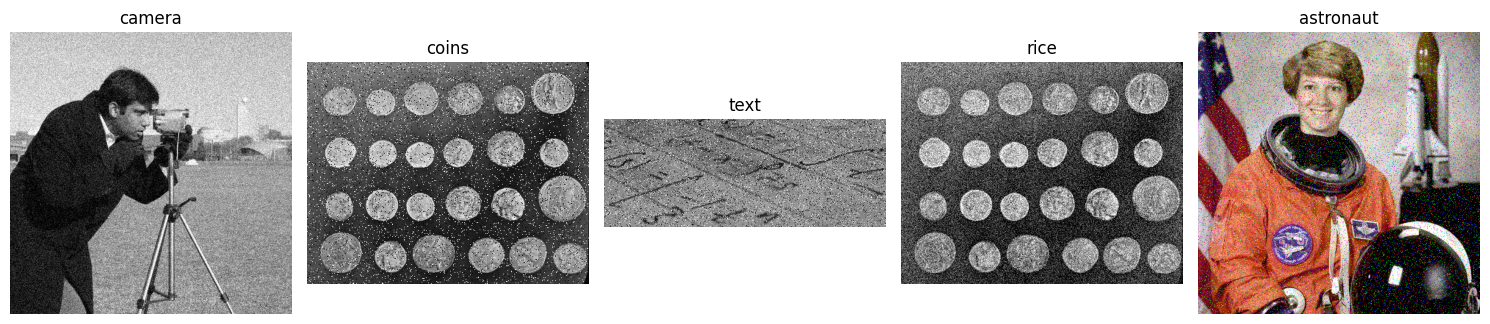

In [22]:
plt.figure(figsize=(15, 4))

for i, name in enumerate(image_names, start=1):
    noisy = load_image(os.path.join("dataset", "noisy", f"{name}_noisy.png"))
    cmap = "gray" if len(noisy.shape) == 2 else None

    plt.subplot(1, len(image_names), i)
    plt.imshow(noisy, cmap=cmap)
    plt.title(f"{name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# These are the types of noises for images we have:

- ### **camera**: Gaussian
- ### **coins**: Salt-and-pepper
- ### **text**: Salt-and-pepper
- ### **rice**: Gaussian
- ### **astronaut**: Salt-and-pepper

# Setup of main Functions

In [25]:
# At least three settings are tested for each method.
spatial_kernel_sizes = [3, 5, 7, 9]
frequency_cutoffs = [10, 20, 40, 80]

# -------------------------
# Evaluation metrics
# -------------------------
def evaluate(clean, denoised):
    clean = clean.astype(np.uint8)
    denoised = np.clip(denoised, 0, 255).astype(np.uint8)

    psnr_value = psnr(clean, denoised, data_range=255)

    if len(clean.shape) == 3:
        ssim_value = ssim(clean, denoised, channel_axis=-1, data_range=255)
    else:
        ssim_value = ssim(clean, denoised, data_range=255)

    return psnr_value, ssim_value


# -------------------------
# Method 1: Spatial-domain denoising
# -------------------------
def spatial_denoising(img, kernel_size=3):
    """
    Median filtering in the spatial domain.

    The median filter is selected because it is effective for impulse
    noise such as salt-and-pepper noise and preserves edges better than
    averaging filters when isolated outliers are present.
    """
    if kernel_size % 2 == 0 or kernel_size < 3:
        raise ValueError("Median filter kernel_size must be an odd integer >= 3.")

    return cv2.medianBlur(img, kernel_size)


# -------------------------
# Method 2: Frequency-domain Gaussian low-pass filter
# -------------------------
def gaussian_lowpass_filter(shape, cutoff):
    """
    Create a Gaussian low-pass filter for a grayscale image shape.

    cutoff controls the amount of smoothing:
    lower cutoff = stronger smoothing, higher cutoff = weaker smoothing.
    """
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    u = np.arange(rows)
    v = np.arange(cols)
    V, U = np.meshgrid(v, u)

    distance_squared = (U - crow) ** 2 + (V - ccol) ** 2
    H = np.exp(-distance_squared / (2 * cutoff ** 2))

    return H


def frequency_gaussian_denoising_gray(img_gray, cutoff=40):
    """Apply Gaussian low-pass filtering in the frequency domain to one channel."""
    img_float = img_gray.astype(np.float32)

    # Fourier transform.
    F = np.fft.fft2(img_float)

    # Shift the zero-frequency component to the center.
    F_shifted = np.fft.fftshift(F)

    # Build and apply the Gaussian low-pass filter in frequency space.
    H = gaussian_lowpass_filter(img_gray.shape, cutoff)
    G_shifted = F_shifted * H

    # Shift back and apply inverse Fourier transform.
    G = np.fft.ifftshift(G_shifted)
    img_filtered = np.fft.ifft2(G)

    img_filtered = np.real(img_filtered)
    img_filtered = np.clip(img_filtered, 0, 255)

    return img_filtered.astype(np.uint8)


def frequency_gaussian_denoising(img, cutoff=40):
    """
    Apply Gaussian low-pass filtering in the frequency domain.

    Works for grayscale and RGB images. RGB images are filtered one channel at a time.
    """
    if len(img.shape) == 2:
        return frequency_gaussian_denoising_gray(img, cutoff)

    channels = [frequency_gaussian_denoising_gray(img[:, :, c], cutoff) for c in range(img.shape[2])]
    return np.stack(channels, axis=2)

# Main experiment



Processing image: camera
Noisy input: PSNR=20.42, SSIM=0.2951
Spatial median, kernel=3: PSNR=25.71, SSIM=0.4939
Spatial median, kernel=5: PSNR=26.21, SSIM=0.6040
Spatial median, kernel=7: PSNR=25.48, SSIM=0.6442
Spatial median, kernel=9: PSNR=24.41, SSIM=0.6469
Frequency Gaussian, cutoff=10: PSNR=20.54, SSIM=0.5714
Frequency Gaussian, cutoff=20: PSNR=22.57, SSIM=0.6268
Frequency Gaussian, cutoff=40: PSNR=25.04, SSIM=0.6879
Frequency Gaussian, cutoff=80: PSNR=26.94, SSIM=0.6403


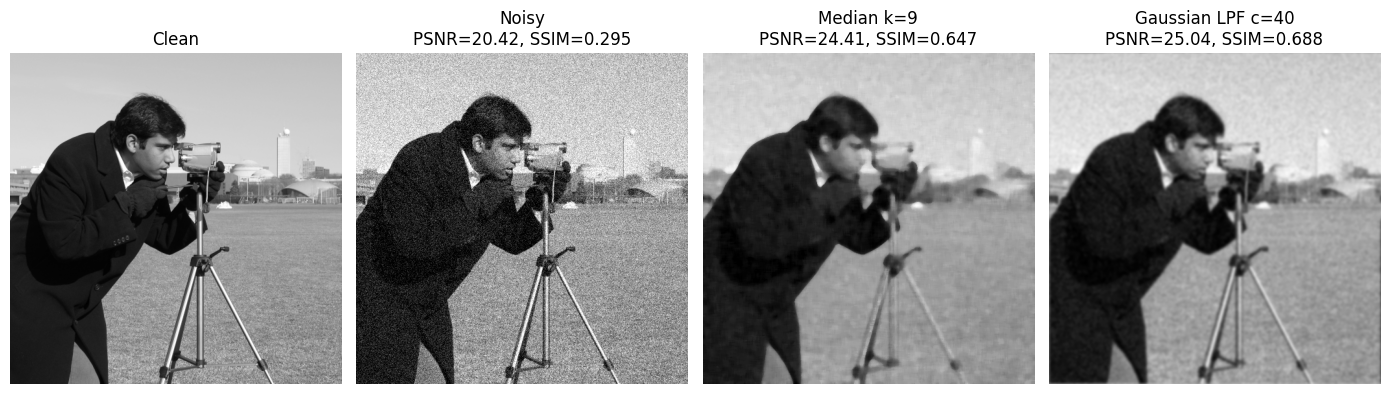


Processing image: coins
Noisy input: PSNR=16.14, SSIM=0.3079
Spatial median, kernel=3: PSNR=28.07, SSIM=0.8536
Spatial median, kernel=5: PSNR=26.17, SSIM=0.7710
Spatial median, kernel=7: PSNR=25.12, SSIM=0.7262
Spatial median, kernel=9: PSNR=24.30, SSIM=0.6936
Frequency Gaussian, cutoff=10: PSNR=19.40, SSIM=0.4628
Frequency Gaussian, cutoff=20: PSNR=21.61, SSIM=0.5585
Frequency Gaussian, cutoff=40: PSNR=23.38, SSIM=0.5748
Frequency Gaussian, cutoff=80: PSNR=22.50, SSIM=0.4816


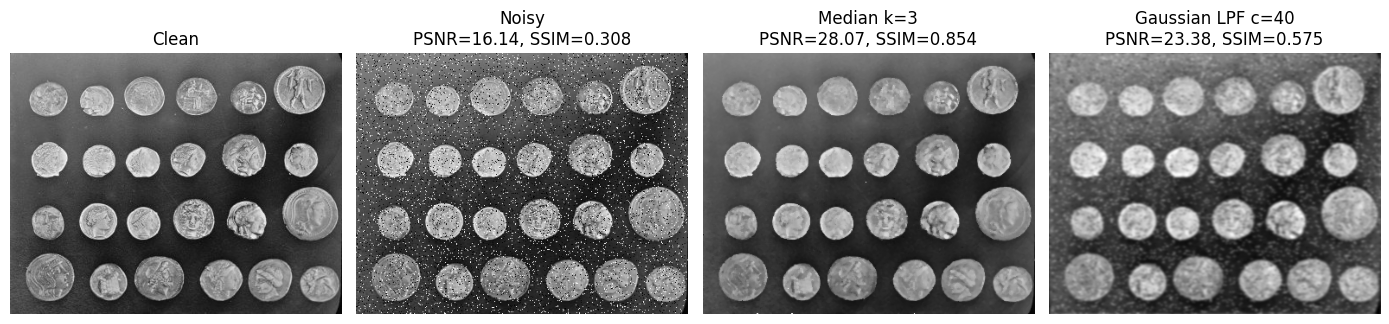


Processing image: text
Noisy input: PSNR=15.05, SSIM=0.1681
Spatial median, kernel=3: PSNR=32.01, SSIM=0.9043
Spatial median, kernel=5: PSNR=28.51, SSIM=0.8240
Spatial median, kernel=7: PSNR=25.48, SSIM=0.7166
Spatial median, kernel=9: PSNR=23.76, SSIM=0.6270
Frequency Gaussian, cutoff=10: PSNR=23.71, SSIM=0.5779
Frequency Gaussian, cutoff=20: PSNR=25.59, SSIM=0.6524
Frequency Gaussian, cutoff=40: PSNR=25.33, SSIM=0.5466
Frequency Gaussian, cutoff=80: PSNR=21.26, SSIM=0.3501


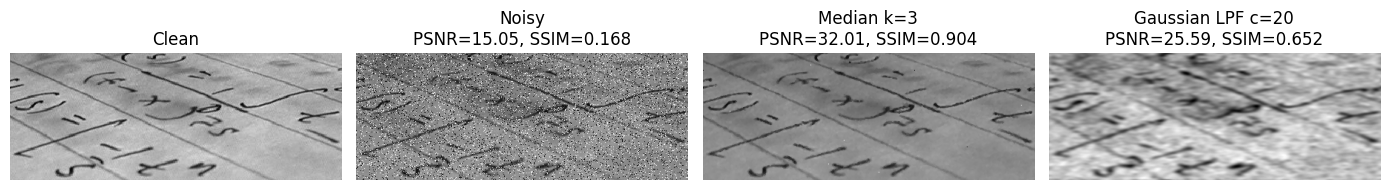


Processing image: rice
Noisy input: PSNR=17.39, SSIM=0.2941
Spatial median, kernel=3: PSNR=23.03, SSIM=0.4602
Spatial median, kernel=5: PSNR=23.78, SSIM=0.5393
Spatial median, kernel=7: PSNR=23.34, SSIM=0.5659
Spatial median, kernel=9: PSNR=22.75, SSIM=0.5644
Frequency Gaussian, cutoff=10: PSNR=19.69, SSIM=0.4630
Frequency Gaussian, cutoff=20: PSNR=22.02, SSIM=0.5731
Frequency Gaussian, cutoff=40: PSNR=24.14, SSIM=0.6168
Frequency Gaussian, cutoff=80: PSNR=23.75, SSIM=0.5054


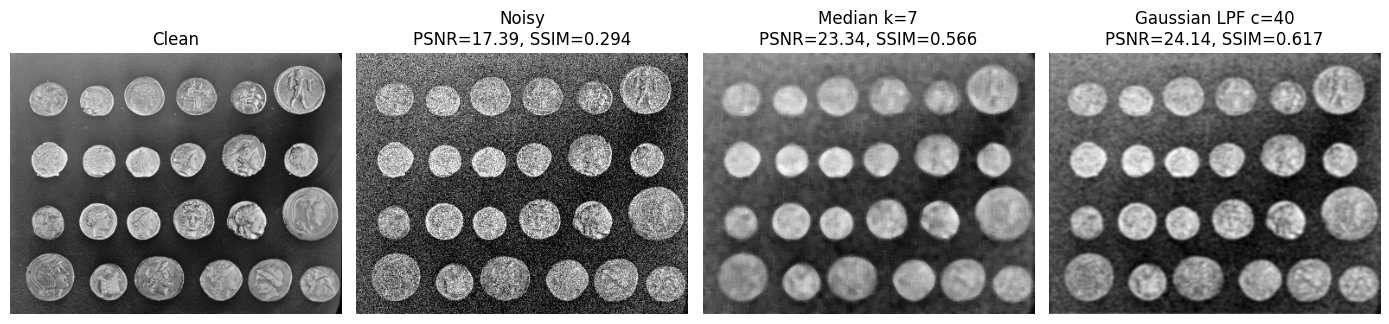


Processing image: astronaut
Noisy input: PSNR=14.56, SSIM=0.2424
Spatial median, kernel=3: PSNR=30.32, SSIM=0.9375
Spatial median, kernel=5: PSNR=27.59, SSIM=0.8926
Spatial median, kernel=7: PSNR=25.71, SSIM=0.8461
Spatial median, kernel=9: PSNR=24.36, SSIM=0.8019
Frequency Gaussian, cutoff=10: PSNR=17.13, SSIM=0.4188
Frequency Gaussian, cutoff=20: PSNR=19.82, SSIM=0.5283
Frequency Gaussian, cutoff=40: PSNR=22.33, SSIM=0.6044
Frequency Gaussian, cutoff=80: PSNR=22.84, SSIM=0.5150


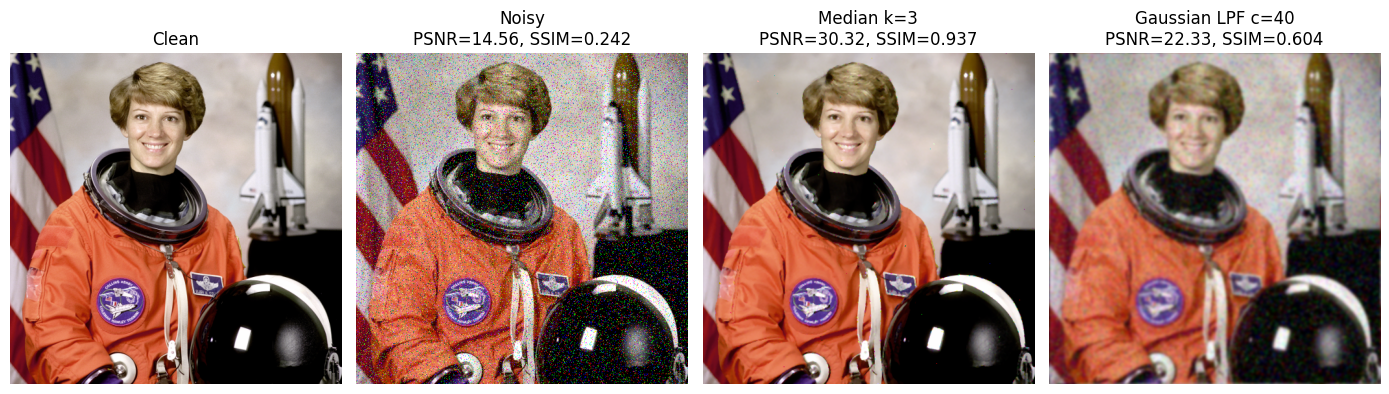

In [27]:
results = []
tuning_results = []
best_images = {}

for name in image_names:
    clean_path = os.path.join(DATASET, "clean", f"{name}.png")
    noisy_path = os.path.join(DATASET, "noisy", f"{name}_noisy.png")

    clean = load_image(clean_path)
    noisy = load_image(noisy_path)

    print(f"\nProcessing image: {name}")

    noisy_psnr, noisy_ssim = evaluate(clean, noisy)
    print(f"Noisy input: PSNR={noisy_psnr:.2f}, SSIM={noisy_ssim:.4f}")

    # -------------------------
    # Spatial-domain experiments
    # -------------------------
    best_spatial = None
    best_spatial_score = -1
    best_spatial_params = None
    best_spatial_metrics = None

    for k in spatial_kernel_sizes:
        denoised_spatial = spatial_denoising(noisy, kernel_size=k)
        p, s = evaluate(clean, denoised_spatial)

        tuning_results.append([name, "Spatial", f"Median, kernel={k}", p, s])
        print(f"Spatial median, kernel={k}: PSNR={p:.2f}, SSIM={s:.4f}")

        # Select best result based on SSIM.
        if s > best_spatial_score:
            best_spatial_score = s
            best_spatial = denoised_spatial
            best_spatial_params = k
            best_spatial_metrics = (p, s)

    # -------------------------
    # Frequency-domain experiments
    # -------------------------
    best_frequency = None
    best_frequency_score = -1
    best_frequency_params = None
    best_frequency_metrics = None

    for cutoff in frequency_cutoffs:
        denoised_frequency = frequency_gaussian_denoising(noisy, cutoff=cutoff)
        p, s = evaluate(clean, denoised_frequency)

        tuning_results.append([name, "Frequency", f"Gaussian LPF, cutoff={cutoff}", p, s])
        print(f"Frequency Gaussian, cutoff={cutoff}: PSNR={p:.2f}, SSIM={s:.4f}")

        # Select best result based on SSIM.
        if s > best_frequency_score:
            best_frequency_score = s
            best_frequency = denoised_frequency
            best_frequency_params = cutoff
            best_frequency_metrics = (p, s)

    # Store best results.
    results.append([name, "Spatial", f"Median, kernel={best_spatial_params}", best_spatial_metrics[0], best_spatial_metrics[1]])
    results.append([name, "Frequency", f"Gaussian LPF, cutoff={best_frequency_params}", best_frequency_metrics[0], best_frequency_metrics[1]])

    best_images[name] = {
        "clean": clean,
        "noisy": noisy,
        "spatial": best_spatial,
        "frequency": best_frequency,
        "spatial_params": best_spatial_params,
        "frequency_params": best_frequency_params,
    }

    # -------------------------
    # Display visual results
    # -------------------------
    cmap = "gray" if len(clean.shape) == 2 else None

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(clean, cmap=cmap)
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(noisy, cmap=cmap)
    plt.title(f"Noisy\nPSNR={noisy_psnr:.2f}, SSIM={noisy_ssim:.3f}")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(best_spatial, cmap=cmap)
    plt.title(f"Median k={best_spatial_params}\nPSNR={best_spatial_metrics[0]:.2f}, SSIM={best_spatial_metrics[1]:.3f}")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(best_frequency, cmap=cmap)
    plt.title(f"Gaussian LPF c={best_frequency_params}\nPSNR={best_frequency_metrics[0]:.2f}, SSIM={best_frequency_metrics[1]:.3f}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Full parameter tuning table

In [35]:
# -------------------------
# Full parameter tuning table
# -------------------------
print("\nFull Parameter Tuning Results")
print("-" * 95)
print(f"{'Image':12s} {'Method':12s} {'Parameters':32s} {'PSNR':>10s} {'SSIM':>10s}")
print("-" * 95)

for row in tuning_results:
    print(
        f"{row[0]:12s} | "
        f"{row[1]:12s} | "
        f"{row[2]:32s} | "
        f"{row[3]:10.2f} | "
        f"{row[4]:10.4f}"
    )


Full Parameter Tuning Results
-----------------------------------------------------------------------------------------------
Image        Method       Parameters                             PSNR       SSIM
-----------------------------------------------------------------------------------------------
camera       | Spatial      | Median, kernel=3                 |      25.71 |     0.4939
camera       | Spatial      | Median, kernel=5                 |      26.21 |     0.6040
camera       | Spatial      | Median, kernel=7                 |      25.48 |     0.6442
camera       | Spatial      | Median, kernel=9                 |      24.41 |     0.6469
camera       | Frequency    | Gaussian LPF, cutoff=10          |      20.54 |     0.5714
camera       | Frequency    | Gaussian LPF, cutoff=20          |      22.57 |     0.6268
camera       | Frequency    | Gaussian LPF, cutoff=40          |      25.04 |     0.6879
camera       | Frequency    | Gaussian LPF, cutoff=80          |      26.

# Final best-results table

In [37]:
print("\nFinal Best Results")
print("-" * 95)
print(f"{'Image':12s} {'Method':12s} {'Best Parameters':32s} {'PSNR':>10s} {'SSIM':>10s}")
print("-" * 95)

for row in results:
    print(
        f"{row[0]:12s} "
        f"{row[1]:12s} "
        f"{row[2]:32s} "
        f"{row[3]:10.2f} "
        f"{row[4]:10.4f}"
    )

spatial_psnr = [r[3] for r in results if r[1] == "Spatial"]
spatial_ssim = [r[4] for r in results if r[1] == "Spatial"]
frequency_psnr = [r[3] for r in results if r[1] == "Frequency"]
frequency_ssim = [r[4] for r in results if r[1] == "Frequency"]

print("\nAverage Results")
print("-" * 60)
print(f"Spatial Method   : PSNR = {np.mean(spatial_psnr):.2f}, SSIM = {np.mean(spatial_ssim):.4f}")
print(f"Frequency Method : PSNR = {np.mean(frequency_psnr):.2f}, SSIM = {np.mean(frequency_ssim):.4f}")


Final Best Results
-----------------------------------------------------------------------------------------------
Image        Method       Best Parameters                        PSNR       SSIM
-----------------------------------------------------------------------------------------------
camera       Spatial      Median, kernel=9                      24.41     0.6469
camera       Frequency    Gaussian LPF, cutoff=40               25.04     0.6879
coins        Spatial      Median, kernel=3                      28.07     0.8536
coins        Frequency    Gaussian LPF, cutoff=40               23.38     0.5748
text         Spatial      Median, kernel=3                      32.01     0.9043
text         Frequency    Gaussian LPF, cutoff=20               25.59     0.6524
rice         Spatial      Median, kernel=7                      23.34     0.5659
rice         Frequency    Gaussian LPF, cutoff=40               24.14     0.6168
astronaut    Spatial      Median, kernel=3                 